# Projeto de classificação de pacientes que possuem diabetes analisando dados médicos
Autores:

Data:

Versão: 1.0

# 1. Introdução

O objetivo será construir uma solução inicial com foco em IA para processamento de exames médicos e documentos clínicos, aplicando fundamentos essenciais de IA e Machine Learning para classificar se o paciente possui ou não diabetes com base nos exames médicos.

## Contexto do Problema:

 O diabetes é uma doença crônica de alta prevalência global, e a detecção precoce através de dados clínicos pode melhorar significativamente o prognóstico do paciente.

## Descrição do Dataset:

O dataset contém as seguintes features:

- gender (gênero)
- age (idade)
- hypertension (hipertensão)
- heart_disease (doença cardíaca)
- smoking_history (histórico de tabagismo)
- bmi (índice de massa corporal)
- HbA1c_level (nível de HbA1c)
- blood_glucose_level (nível de glicose no sangue)

A variável alvo é `diabetes`, que indica se o paciente tem (valor 1) ou não (valor 0) a doença.

## Objetivos:

Realizar análise exploratória dos dados, entender como eles se comportam para escolha do modelo mais apropriado.

Treino de um ou mais modelos, utilizando diferentes algoritmos de machine learning para aprender o padrão/comportamento dos dados.

Utilizar métricas para avaliar o treinamento dos modelos, comparar diferentes possibilidades, e por fim, selecionar o modelo com melhor desempenho.

# 2. Configuração do Ambiente

Importação de todas as bibliotecas necessárias para a realização do projeto.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
import shap

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier


TRANSLATIONS_STATISTICS = {
    'count': 'Contagem',
    'mean': 'Média',
    'std': 'Desvio Padrão',
    'min': 'Mínimo',
    '25%': '1º Quartil (25%)',
    '50%': 'Mediana (50%)',
    '75%': '3º Quartil (75%)',
    'max': 'Máximo'
}

# 3. Carregamento dos Dados

Escolhemos o `dataset` [Diabetes prediction dataset
](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset/data), disponível no `Kaggle`, a escolha foi baseada no volume de dados e no balanceamento realista dos casos de pacientes com diabetes e sem diabetes (10% dos pacientes possuem diabetes). O mesmo deve ser baixado e adicionado a sessão para que seja possível a utilização do mesmo.

Uma vez que o arquivo esteja disponível, criamos o `dataframe` com o `Pandas`.

In [4]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

# 4. Análise Exploratória de Dados (EDA - Exploratory Data Analysis)


## 4.1 Visão geral dos dados

Vamos exibir as primeiras 5 linhas do `DataFrame` para ter uma visão geral dos dados, suas colunas e formatos, assegurando que as informações foram carregadas com sucesso.

In [5]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Total linhas e colunas no `dataset`, detalhando um pouco mais nossas dimensões.

In [6]:
df.shape

(100000, 9)

Resumo estatístico das colunas numéricas, incluindo contagem, média, desvio padrão, valores mínimos e máximos, e quartis. Nos ajuda a identificar a distribuição dos dados e eventualmente, outliers.

In [7]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Resumo do `DataFrame`, com o tipo de dado de cada coluna (numérico, objeto, etc.) e o número de valores não nulos. Essencial para identificar valores faltantes e planejar o pré-processamento dos dados.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


Número de ocorrências para cada valor na coluna `diabetes` (nossa variável alvo). Importante para entender o desbalanceamento das classes, por exemplo, podem haver muito mais casos de não-diabetes do que diabetes e isso pode influenciar na escolha do modelo.


In [9]:
df['diabetes'].value_counts()

,count
diabetes,
0,91500
1,8500


## 4.2 Análise por categoria

### 4.2.1 Smoking History (Histórico de Tabagismo)

**Pergunta:** O histórico de tabagismo está associado à diabetes?

In [10]:
df["smoking_history"].value_counts()

,count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


In [11]:
smoking_history_diabetes_proportions = df.groupby("smoking_history")["diabetes"].value_counts(normalize=True)
print(smoking_history_diabetes_proportions)

smoking_history  diabetes
No Info          0           0.959404
                 1           0.040596
current          0           0.897911
                 1           0.102089
ever             0           0.882118
                 1           0.117882
former           0           0.829983
                 1           0.170017
never            0           0.904659
                 1           0.095341
not current      0           0.892973
                 1           0.107027
Name: proportion, dtype: float64


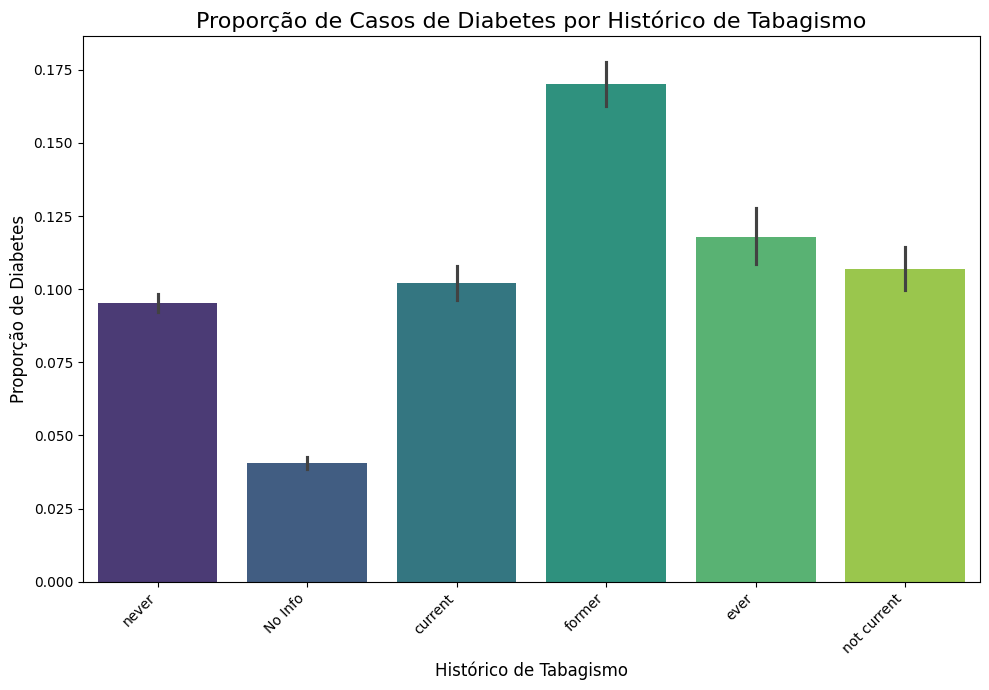

In [12]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x="smoking_history",
    y="diabetes",
    data=df,
    palette="viridis",
    hue="smoking_history",
    legend=False
  )

plt.title("Proporção de Casos de Diabetes por Histórico de Tabagismo", fontsize=16)
plt.xlabel("Histórico de Tabagismo", fontsize=12)
plt.ylabel("Proporção de Diabetes", fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**former** (ex-fumantes) → têm a maior proporção de diabetes (cerca de 17%).

**ever** (que já fumaram alguma vez) e current (fumantes atuais) também têm proporções mais altas, na faixa de 10–12%.

**never** (nunca fumaram) e **No Info** têm proporções mais baixas — abaixo de 10%.

**Isso pode indicar uma correlação:**

Pacientes que fumam ou já fumaram tendem a ter maior prevalência de diabetes do que os que nunca fumaram, precisa ser analisado se a correlação é estatisticamente significativa.

Podemos utilizar do método Qui-Quadrado (Chi-Square Test)

Esse teste avalia se há associação estatística entre duas variáveis categóricas.
No caso: smoking_history e diabetes.

### Qui-Quadrado (smoking_history e diabetes)

In [13]:
contingency = pd.crosstab(df['smoking_history'], df['diabetes'])

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Qui-quadrado: {chi2:.2f}")
print(f"Graus de liberdade: {dof}")
print(f"p-valor: {p:.6f}")

if p < 0.05:
    print("Há evidência estatística de associação entre fumar e diabetes (p < 0.05).")
else:
    print("Não há evidência significativa de associação (p ≥ 0.05).")


Qui-quadrado: 1956.09
Graus de liberdade: 5
p-valor: 0.000000
Há evidência estatística de associação entre fumar e diabetes (p < 0.05).


Foi identificada uma associação estatisticamente significativa entre o histórico de tabagismo e a presença de diabetes (teste qui-quadrado, p < 0,05).
Pacientes ex-fumantes e fumantes atuais apresentaram maior prevalência de diabetes em comparação aqueles que nunca fumaram.
Diante desse resultado, a variável smoking_history pode ser considerada relevante e incluída como feature de entrada no treinamento do modelo preditivo.

### 4.2.2 Age (Idade)

**Pergunta:** A média (ou a distribuição) das idades é significativamente diferente entre pessoas com e sem diabetes?

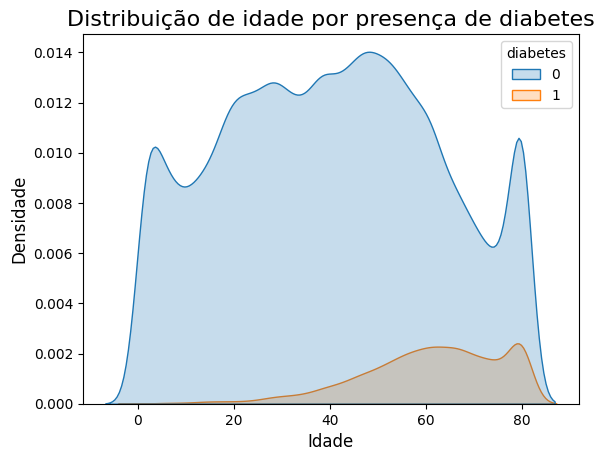

In [14]:
sns.kdeplot(data=df, x='age', hue='diabetes', fill=True)
plt.title('Distribuição de idade por presença de diabetes', fontsize=16)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.show()


In [15]:
stats = df.groupby('diabetes')['age'].describe()

stats = stats.T.rename(index=TRANSLATIONS_STATISTICS).round(2)

stats

diabetes,0,1
Contagem,91500.00,8500.00
Média,40.12,60.95
Desvio Padrão,22.31,14.55
Mínimo,0.08,3.00
1º Quartil (25%),22.00,52.00
Mediana (50%),40.00,62.00
3º Quartil (75%),57.00,72.00
Máximo,80.00,80.00


Ao analisar os agrupamentos de pacientes com e sem diabetes em relação à idade, observamos que:

A média de idade dos pacientes sem diabetes é de aproximadamente 40 anos, enquanto nos pacientes com diabetes é de cerca de 60 anos.

**Os valores de 1º quartil, mediana e 3º quartil** seguem o mesmo padrão, indicando que os pacientes com diabetes tendem a ser mais velhos do que os pacientes sem a doença.

**Esses resultados sugerem uma possível relação entre idade e presença de diabetes.**

Para verificar essa diferença de forma estatística, precisamos responder à seguinte pergunta:
A média (ou a distribuição) das idades é significativamente diferente entre pessoas com e sem diabetes?

Como age é uma variável numérica contínua e diabetes é binária (0 ou 1), o teste mais indicado é o Teste t de Student para amostras independentes.
Esse teste permite comparar as médias de dois grupos e determinar se a diferença observada (por exemplo, média de 60 anos para pacientes com diabetes e 40 anos para pacientes sem diabetes) é estatisticamente significativa ou se poderia ter ocorrido por acaso.

### Teste t student (age e diaebetes)

In [16]:
diabetic = df[df['diabetes'] == 1]['age']
non_diabetic = df[df['diabetes'] == 0]['age']

t_stat, p = ttest_ind(diabetic, non_diabetic, equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-valor: {p:.6f}")

if p < 0.05:
    print("Diferença significativa de idade entre diabéticos e não diabéticos (p < 0.05).")
else:
    print("Não há diferença significativa de idade (p ≥ 0.05).")


T-statistic: 119.59
P-valor: 0.000000
Diferença significativa de idade entre diabéticos e não diabéticos (p < 0.05).


Foi observada uma diferença estatisticamente significativa entre as idades de pacientes com e sem diabetes (teste t de Student, p < 0,05).
Em média, pacientes diabéticos apresentaram idade superior aos não diabéticos, indicando uma possível associação entre envelhecimento e maior prevalência de diabetes.
Dessa forma, a variável age pode ser considerada relevante e incluída como feature de entrada no treinamento do modelo preditivo.

### 4.2.3 Gender (Genêro)

**Pergunta:** Há diferença na proporção de diabetes entre homens e mulheres?

In [17]:
df["gender"].value_counts()

,count
gender,
Female,58552
Male,41430
Other,18


In [18]:
contingency_gender = pd.crosstab(df['gender'], df['diabetes'], normalize="index") * 100
contingency_gender = contingency_gender.rename(index={'Female': 'Feminino', 'Male': 'Masculino', 'Other': 'Outro'})
contingency_gender

diabetes,0,1
gender,,
Feminino,92.381131,7.618869
Masculino,90.251026,9.748974
Outro,100.000000,0.000000


In [19]:
proportions = (contingency_gender.div(contingency_gender.sum(axis=1), axis=0) * 100).round(2)
proportions


diabetes,0,1
gender,,
Feminino,92.38,7.62
Masculino,90.25,9.75
Outro,100.00,0.00


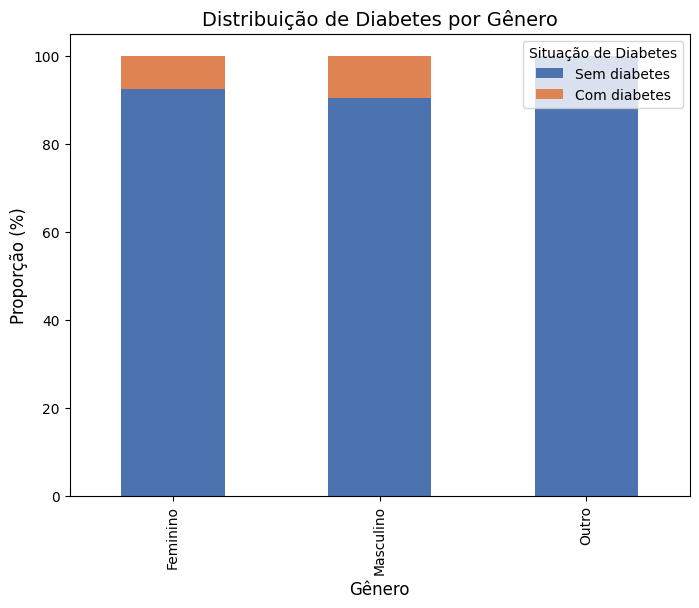

In [20]:

contingency_gender.columns = ["Sem diabetes", "Com diabetes"]

contingency_gender.plot(
    kind="bar",
    stacked=True,
    color=["#4c72b0", "#dd8452"],  # azul e laranja
    figsize=(8, 6)
)

plt.title("Distribuição de Diabetes por Gênero", fontsize=14)
plt.xlabel("Gênero", fontsize=12)
plt.ylabel("Proporção (%)", fontsize=12)
plt.legend(title="Situação de Diabetes")
plt.show()


Analisando os dados podemos visualizar que homens têm uma proporção ligeiramente maior de diabetes em relação às mulheres.

Podemos utilizar do método Qui-Quadrado (Chi-Square Test)

Iremos avalair se há associação estatística entre duas variáveis categóricas. No caso: gender e diabetes.

### Qui-Quadrado (gender e diabetes)

In [21]:

chi2, p, dof, expected = chi2_contingency(contingency_gender)

print(f"Qui-quadrado: {chi2:.2f}")
print(f"p-valor: {p:.6f}")

if p < 0.05:
    print("Há associação estatisticamente significativa entre gênero e diabetes (p < 0.05).")
else:
    print("Não há evidência significativa de associação (p ≥ 0.05).")


Qui-quadrado: 9.63
p-valor: 0.008093
Há associação estatisticamente significativa entre gênero e diabetes (p < 0.05).


O teste qui-quadrado mostrou associação estatisticamente significativa entre gênero e presença de diabetes (este qui-quadrado, p < 0,05).
Homens apresentaram maior prevalência de diabetes em comparação às mulheres.
Embora a diferença relativa não seja grande (2.13%), essa variável poderá ser utilizada como uma feature candidata no modelo de predição.
Posteriormente, será avaliado o impacto do gender na performance do modelo, comparando versões com e sem essa variável.

### 4.2.4 BMI (Índice de Massa Corporal)

**Pergunta:** Pessoas com diabetes têm IMC médio maior?

In [22]:
stats = df.groupby("diabetes")["bmi"].describe()

stats = stats.T.rename(index=TRANSLATIONS_STATISTICS).round(2)

stats


diabetes,0,1
Contagem,91500.00,8500.00
Média,26.89,31.99
Desvio Padrão,6.37,7.56
Mínimo,10.01,10.98
1º Quartil (25%),23.24,27.32
Mediana (50%),27.32,29.97
3º Quartil (75%),28.87,35.91
Máximo,95.69,88.72


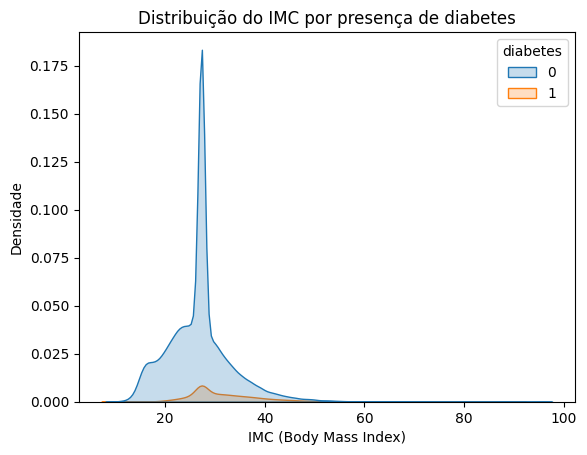

In [23]:
sns.kdeplot(data=df, x="bmi", hue="diabetes", fill=True)
plt.title("Distribuição do IMC por presença de diabetes")
plt.xlabel("IMC (Body Mass Index)")
plt.ylabel("Densidade")
plt.show()


In [24]:
def categorize_bmi(bmi):
    if bmi < 18.5:
        return "Abaixo do peso"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Sobrepeso"
    elif bmi < 35:
        return "Obesidade I"
    elif bmi < 40:
        return "Obesidade II"
    else:
        return "Obesidade III"

df["bmi_category"] = df["bmi"].apply(categorize_bmi)
pd.crosstab(df["bmi_category"], df["diabetes"], normalize="index") * 100


diabetes,0,1
bmi_category,,
Abaixo do peso,99.246527,0.753473
Normal,96.115937,3.884063
Obesidade I,85.569600,14.430400
Obesidade II,80.576238,19.423762
Obesidade III,74.139797,25.860203
Sobrepeso,92.699613,7.300387


Analisando os dados comparativos de bmi (Índice de Massa Corporal) podemos observar que os pacientes com diabetes tendem a ter um maior índice de massa corporal comparado aos pacientes sem diabetes:

**Média bmi de pacientes sem diabetes:**	26.89

**Média bmi de pacientes com diaebetes:** 31.99

**Os valores de 1º quartil, mediana e 3º quartil seguem o mesmo padrão**, indicando que a prevalência de diabetes aumenta conforme as faixas de IMC sobem, reforçando o papel da obesidade como fator de risco.

Para verificar essa diferença de forma estatística, precisamos responder à seguinte pergunta: Pessoas com diabetes têm IMC médio maior?

Como bmi é uma variável numérica contínua e diabetes é binária (0 ou 1), o teste mais indicado é o Teste t de Student para amostras independentes. Esse teste permite comparar as médias de dois grupos e determinar se a diferença observada (por exemplo, média de imc de pacientes com e sem diabetes) é estatisticamente significativa ou se poderia ter ocorrido por acaso.

### Teste t student (bmi e diaebetes)

In [25]:
bmi_diabetes = df[df["diabetes"] == 1]["bmi"]
bmi_no_diabetes = df[df["diabetes"] == 0]["bmi"]

t_stat, p_value = ttest_ind(bmi_diabetes, bmi_no_diabetes, equal_var=False)

print(f"t = {t_stat:.2f}, p = {p_value:.6f}")

if p_value < 0.05:
    print("Diferença estatisticamente significativa entre os grupos (p < 0.05).")
else:
    print("Diferença não significativa (p ≥ 0.05).")


t = 60.27, p = 0.000000
Diferença estatisticamente significativa entre os grupos (p < 0.05).


O teste t de Student mostrou diferença significativa entre os grupos (p < 0.05), indicando que pacientes com diabetes apresentam IMC médio mais alto.

Observa-se que a prevalência de diabetes aumenta conforme as faixas de IMC sobem, reforçando o papel da obesidade como fator de risco.

**Referência clínica e classificação de IMC**

De acordo com a OMS, a faixa de IMC a partir de 30 kg/m² é classificada como obesidade, com subdivisões de Classe I, II e III. Indivíduos com IMC entre 25 e 29,9 são considerados em sobrepeso.
Estudos recentes, como "[Body mass index and diabetes risk in fifty-seven low- and middle-income countries](https://pmc.ncbi.nlm.nih.gov/articles/PMC8336025/?utm_source=chatgpt.com)" realizado em 2021, mostram que o risco de diabetes já está significativamente aumentado para IMCs em torno de 23 kg/m² ou mais em certas populações.


No nosso dataset, média de IMC para pacientes com diabetes foi **31.99** kg/m² obesidade classe I. Isso se alinha com o que a literatura sugere: IMC elevado, especialmente acima de 25–30, está correlacionado com aumento de risco de diabetes.
Sendo assim, bmi é uma das variáveis mais relevantes para o modelo preditivo.

### 4.2.5 Hypertension (Hipertensão)

**Pergunta**: Pessoas com hipertensão ou doenças cardíacas têm mais diabetes?

In [26]:
print(df["hypertension"].value_counts())

hypertension
0    92515
1     7485
Name: count, dtype: int64


In [27]:
contingency_hipertension = pd.crosstab(df["hypertension"], df["diabetes"], normalize="index").rename(columns={0: "Não", 1: "Sim"}).rename(index={0: "Sem Hipertensão", 1: "Com Hipertensão"}).rename_axis("Hipertensão") * 100

contingency_hipertension


diabetes,Não,Sim
Hipertensão,,
Sem Hipertensão,93.069232,6.930768
Com Hipertensão,72.104208,27.895792


In [28]:
proportions = (contingency_hipertension.div(contingency_hipertension.sum(axis=1), axis=0) * 100).round(2)
proportions

diabetes,Não,Sim
Hipertensão,,
Sem Hipertensão,93.07,6.93
Com Hipertensão,72.10,27.90


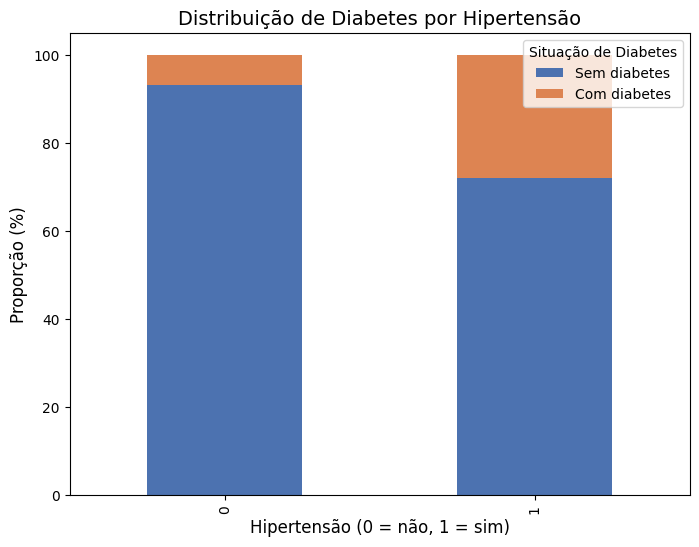

In [29]:

ct = pd.crosstab(df["hypertension"], df["diabetes"], normalize="index") * 100

ct.columns = ["Sem diabetes", "Com diabetes"]

ct.plot(
    kind="bar",
    stacked=True,
    color=["#4c72b0", "#dd8452"],  # azul e laranja
    figsize=(8, 6)
)

plt.title("Distribuição de Diabetes por Hipertensão", fontsize=14)
plt.xlabel("Hipertensão (0 = não, 1 = sim)", fontsize=12)
plt.ylabel("Proporção (%)", fontsize=12)
plt.legend(title="Situação de Diabetes")
plt.show()


Analisando os dados podemos observar que pacientes com hipertensão têm uma proporção maior de diabetes em relação à pacientes sem hipertensão.

**Pacientes com diabetes e hipertensão:** aproximadamente **27.9%**

**Pacientes com diabetes e sem hipertensão:** aproximadamente **6.9%**

Isso quer dizer que pessoas com hipertensão têm quase 4 vezes mais casos de diabetes do que aquelas sem hipertensão.

Essa diferença indica uma associação positiva e forte entre hipertensão e diabetes.
Não é uma relação causal (o gráfico não mostra causa e efeito), mas aponta uma correlação importante:

A prevalência de diabetes é consideravelmente maior em indivíduos hipertensos.

Podemos utilizar do método Qui-Quadrado (Chi-Square Test)

Iremos avalair se há associação estatística entre duas variáveis categóricas. No caso: hipetension e diabetes.

### Qui-Quadrado (hypertension e diabetes)

In [30]:
contingency = pd.crosstab(df['hypertension'], df['diabetes'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Qui-quadrado: {chi2:.2f}")
print(f"p-valor: {p:.6f}")

if p < 0.05:
    print("Há associação estatisticamente significativa entre hipertensão e diabetes (p < 0.05).")
else:
    print("Não há evidência significativa de associação (p ≥ 0.05).")


Qui-quadrado: 3910.71
p-valor: 0.000000
Há associação estatisticamente significativa entre hipertensão e diabetes (p < 0.05).


O teste qui-quadrado mostrou associação estatisticamente significativa entre hipertensão e presença de diabetes (este qui-quadrado, p < 0,05). Pacientes com hipertensão apresentaram maior prevalência de diabetes em comparação à pacientes sem diabetes. Diante desse resultado, a variável hipertension pode ser considerada relevante e incluída como feature de entrada no treinamento do modelo preditivo.

### 4.2.6 Heart Disease (Doença Cardíaca)

**Pergunta:** Pessoas com hipertensão ou doenças cardíacas têm mais diabetes?

In [31]:
print(df["heart_disease"].value_counts(normalize=True) * 100)


heart_disease
0    96.058
1     3.942
Name: proportion, dtype: float64


In [32]:
contingency_heart_disease = pd.crosstab(df["heart_disease"], df["diabetes"], normalize="index").rename(columns={0: "Não", 1: "Sim"}).rename(index={0: "Sem doença cardíaca", 1: "Com doença cardíaca"}).rename_axis("Hipertensão") * 100

contingency_heart_disease


diabetes,Não,Sim
Hipertensão,,
Sem doença cardíaca,92.470174,7.529826
Com doença cardíaca,67.858955,32.141045


In [33]:
proportions = (contingency_heart_disease.div(contingency_heart_disease.sum(axis=1), axis=0) * 100).round(2)
proportions

diabetes,Não,Sim
Hipertensão,,
Sem doença cardíaca,92.47,7.53
Com doença cardíaca,67.86,32.14


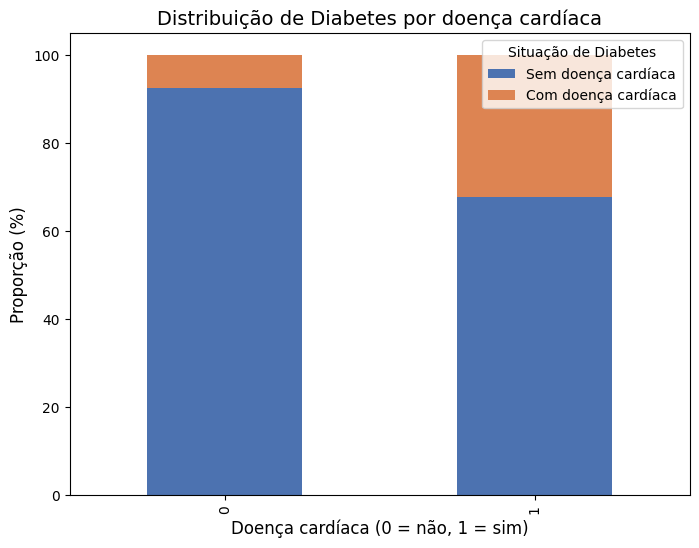

In [34]:
ct = pd.crosstab(df["heart_disease"], df["diabetes"], normalize="index") * 100

ct.columns = ["Sem doença cardíaca", "Com doença cardíaca"]

ct.plot(
    kind="bar",
    stacked=True,
    color=["#4c72b0", "#dd8452"],
    figsize=(8, 6)
)

plt.title("Distribuição de Diabetes por doença cardíaca", fontsize=14)
plt.xlabel("Doença cardíaca (0 = não, 1 = sim)", fontsize=12)
plt.ylabel("Proporção (%)", fontsize=12)
plt.legend(title="Situação de Diabetes")
plt.show()

Analisando os dados podemos observar que pacientes com doenças cardíacas têm uma proporção maior de diabetes em relação à pacientes sem doenças cardíacas.

**Pacientes com diabetes e doenças cardíacas:** aproximadamente **32.14%**

**Pacientes com diabetes e sem doenças cardíacas:** aproximadamente **7.53%**

Isso quer dizer que pessoas com doenças cardíacas têm 4 vezes mais casos de diabetes do que aquelas sem doenças cardíacas.

Essa diferença indica uma associação positiva e forte entre doença cardíaca e diabetes. Não é uma relação causal (o gráfico não mostra causa e efeito), mas aponta uma correlação importante:

A prevalência de diabetes é consideravelmente maior em indivíduos com doença cardíaca.

Podemos utilizar do método Qui-Quadrado (Chi-Square Test)

Iremos avalair se há associação estatística entre duas variáveis categóricas. No caso: heart_disease e diabetes.

### Qui-Quadrado (heart_disease e diabetes)

In [35]:
contingency = pd.crosstab(df['heart_disease'], df['diabetes'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Qui-quadrado: {chi2:.2f}")
print(f"p-valor: {p:.6f}")

if p < 0.05:
    print("Há associação estatisticamente significativa entre doença cardíaca e diabetes (p < 0.05).")
else:
    print("Não há evidência significativa de associação (p ≥ 0.05).")


Qui-quadrado: 2945.85
p-valor: 0.000000
Há associação estatisticamente significativa entre doença cardíaca e diabetes (p < 0.05).


O teste qui-quadrado mostrou associação estatisticamente significativa entre doença cardíaca e presença de diabetes (este qui-quadrado, p < 0,05). Pacientes com doença cardíaca apresentaram maior prevalência de diabetes em comparação à pacientes sem doença cardíaca. Diante desse resultado, a variável heart_disease pode ser considerada relevante e incluída como feature de entrada no treinamento do modelo preditivo.

### 4.2.7 HbA1c_level (Hemoglobina Glicada)

**Pergunta:** O nível médio de HbA1c difere entre pacientes com e sem diabetes?

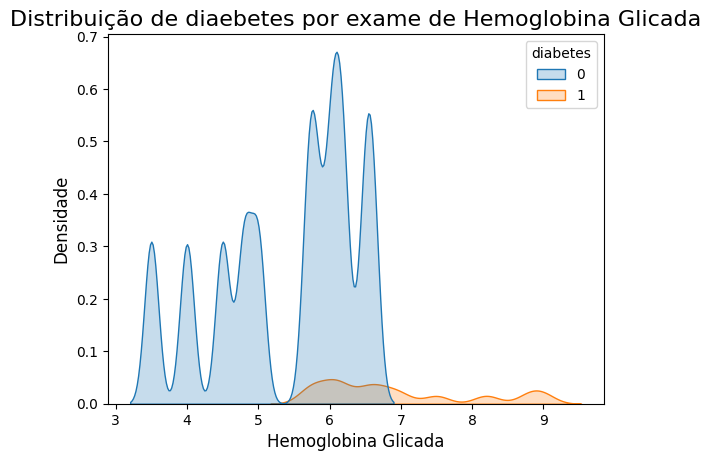

In [36]:
sns.kdeplot(data=df, x='HbA1c_level', hue='diabetes', fill=True)
plt.title('Distribuição de diaebetes por exame de Hemoglobina Glicada', fontsize=16)
plt.xlabel('Hemoglobina Glicada', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.show()

In [37]:
stats = df.groupby('diabetes')['HbA1c_level'].describe()

stats = stats.T.rename(index=TRANSLATIONS_STATISTICS).round(2)

stats

diabetes,0,1
Contagem,91500.00,8500.00
Média,5.40,6.93
Desvio Padrão,0.97,1.08
Mínimo,3.50,5.70
1º Quartil (25%),4.80,6.10
Mediana (50%),5.80,6.60
3º Quartil (75%),6.20,7.50
Máximo,6.60,9.00


Ao analisar os agrupamentos de pacientes observando o exame de Hemoglobina Glicada, notamos que:

**Média:** A média de Hemoglobina Glicada dos pacientes com diabetes é de aproximadamente 6.93, enquanto nos pacientes sem diabetes é de cerca de 5.40.

**Os valores de 1º quartil, mediana e 3º quartil** seguem o mesmo padrão, indicando que os pacientes com diabetes tendem a ter um maior resultado de Hemoglobina Glicada do que os pacientes sem diabetes.

Esses resultados sugerem uma possível relação entre Hemoglobina Glicada e presença de diabetes.

Para verificar essa diferença de forma estatística, precisamos responder à seguinte pergunta: A média (ou a distribuição) do exame de Hemoglobina Glicada é significativamente diferente entre pessoas com e sem diabetes?

Como HbA1c_level é uma variável numérica contínua e diabetes é binária (0 ou 1), o teste mais indicado é o Teste t de Student para amostras independentes. Esse teste permite comparar as médias de dois grupos e determinar se a diferença observada (por exemplo, média de 6.93 de Hemoglobina glicada para pacientes com diabetes e 5.40 de Hemoglobina glicada para pacientes sem diabetes) é estatisticamente significativa ou se poderia ter ocorrido por acaso.

### Teste t student (HbA1c_level e diaebetes)

In [38]:
diabetic = df[df['diabetes'] == 1]['HbA1c_level']
non_diabetic = df[df['diabetes'] == 0]['HbA1c_level']

t_stat, p = ttest_ind(diabetic, non_diabetic, equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-valor: {p:.6f}")

if p < 0.05:
    print("Diferença significativa de Hemoglobina Glicada entre diabéticos e não diabéticos (p < 0.05).")
else:
    print("Não há diferença significativa de Hemoglobina Glicada (p ≥ 0.05).")


T-statistic: 127.01
P-valor: 0.000000
Diferença significativa de Hemoglobina Glicada entre diabéticos e não diabéticos (p < 0.05).


Foi observada uma diferença estatisticamente significativa entre Hemoglobina Glicada de pacientes com e sem diabetes (teste t de Student, p < 0,05). Em média, pacientes diabéticos apresentaram Hemoglobina Glicada superior aos não diabéticos, indicando uma possível associação entre Hemoglobina Glicada e maior prevalência de diabetes. Dessa forma, a variável HbA1c_level pode ser considerada relevante e incluída como feature de entrada no treinamento do modelo preditivo.

### 4.2.8 blood_glucose_level (Nível de glicose no sangue)

**Pergunta:** Pessoas com diabetes apresentam glicemia significativamente maior?

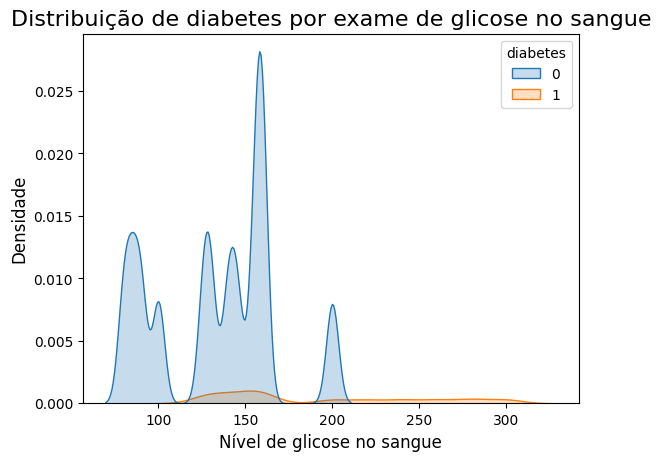

In [39]:
sns.kdeplot(data=df, x='blood_glucose_level', hue='diabetes', fill=True)
plt.title('Distribuição de diabetes por exame de glicose no sangue', fontsize=16)
plt.xlabel('Nível de glicose no sangue', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.show()

In [40]:
stats = df.groupby('diabetes')['blood_glucose_level'].describe()

stats = stats.T.rename(index=TRANSLATIONS_STATISTICS).round(2)

stats

diabetes,0,1
Contagem,91500.00,8500.00
Média,132.85,194.09
Desvio Padrão,34.25,58.64
Mínimo,80.00,126.00
1º Quartil (25%),100.00,145.00
Mediana (50%),140.00,160.00
3º Quartil (75%),158.00,240.00
Máximo,200.00,300.00


Ao analisar os agrupamentos de pacientes observando o exame de Nível de glicose no sangue, notamos que:

**Média:** A média de Nível de glicose no sangue dos pacientes com diabetes é de aproximadamente 194.09, enquanto nos pacientes sem diabetes é de cerca de 132.85.

**Os valores de 1º quartil, mediana e 3º quartil** seguem o mesmo padrão, indicando que os pacientes com diabetes tendem a ter um maior resultado de Nível de glicose no sangue do que os pacientes sem diabetes.

Esses resultados sugerem uma possível relação entre glicose no sangue e presença de diabetes.

Para verificar essa diferença de forma estatística, precisamos responder à seguinte pergunta: A média (ou a distribuição) do nível de glicose no sangue é significativamente diferente entre pessoas com e sem diabetes?

Como blood_glucose_level é uma variável numérica contínua e diabetes é binária (0 ou 1), o teste mais indicado é o Teste t de Student para amostras independentes. Esse teste permite comparar as médias de dois grupos e determinar se a diferença observada (por exemplo, média de glicose no sangue de 194.09  para pacientes com diabetes e glicose no sangue de 132.85 para pacientes sem diabetes) é estatisticamente significativa ou se poderia ter ocorrido por acaso.

### Teste t student (blood_glucose_level e diaebetes)

In [41]:
diabetic = df[df['diabetes'] == 1]['blood_glucose_level']
non_diabetic = df[df['diabetes'] == 0]['blood_glucose_level']

t_stat, p = ttest_ind(diabetic, non_diabetic, equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-valor: {p:.6f}")

if p < 0.05:
    print("Diferença significativa de glicose no sangue entre diabéticos e não diabéticos (p < 0.05).")
else:
    print("Não há diferença significativa de glicose no sangue (p ≥ 0.05).")

T-statistic: 94.79
P-valor: 0.000000
Diferença significativa de glicose no sangue entre diabéticos e não diabéticos (p < 0.05).


Foi observada uma diferença estatisticamente significativa entre glicose no sangue de pacientes com e sem diabetes (teste t de Student, p < 0,05). Em média, pacientes diabéticos apresentaram glicose no sangue superior aos não diabéticos, indicando uma possível associação entre Glicose no sangue e maior prevalência de diabetes. Dessa forma, a variável blood_glucose_level pode ser considerada relevante e incluída como feature de entrada no treinamento do modelo preditivo.

## 4.3 Histograma

O histograma abaixo mostra a distribuição de frequência das variáveis, destacando a concentração de valores e a presença de possíveis outliers.

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'hypertension'}>,
        <Axes: title={'center': 'heart_disease'}>],
       [<Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'HbA1c_level'}>,
        <Axes: title={'center': 'blood_glucose_level'}>],
       [<Axes: title={'center': 'diabetes'}>, <Axes: >, <Axes: >]],
      dtype=object)

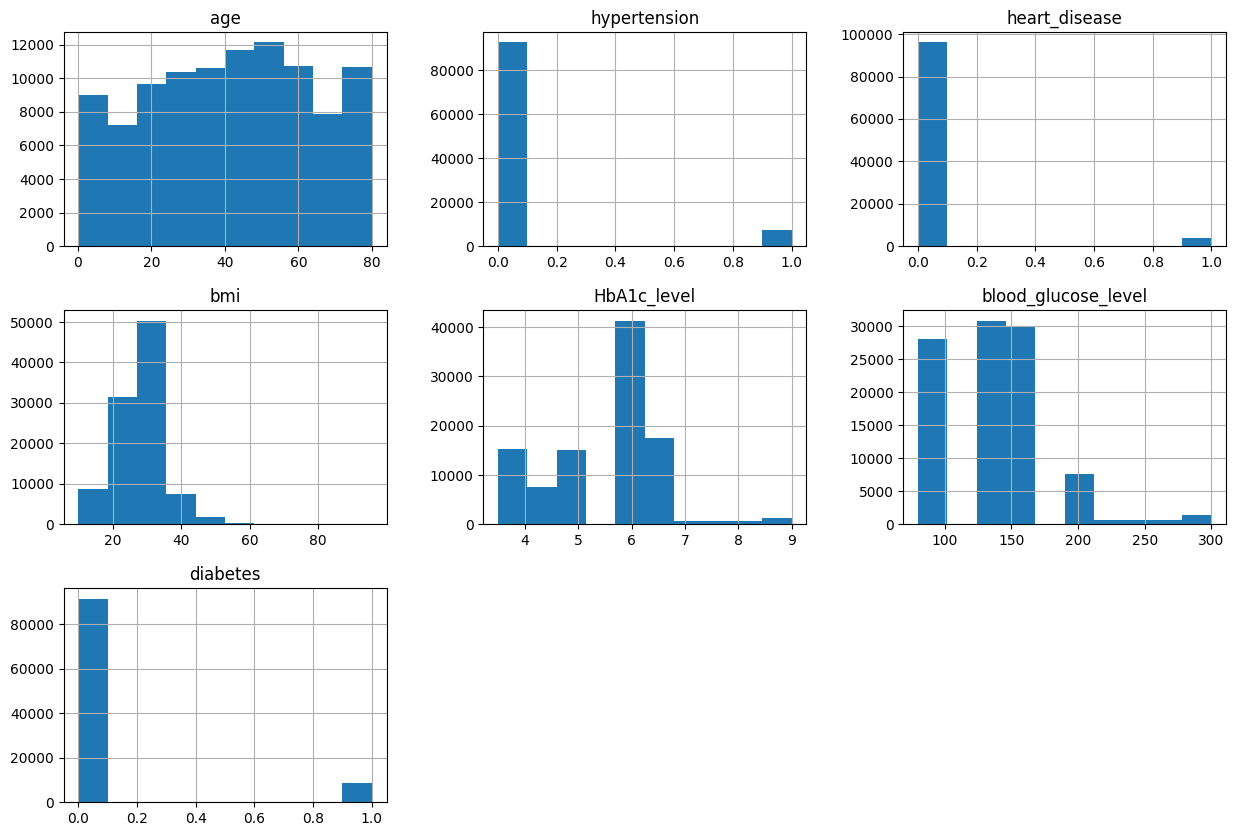

In [42]:
df.hist(figsize=(15, 10))

O gráfico `boxplot` mostra a distribuição de uma variável por meio de quartis, identificando a mediana, a amplitude interquartil e a presença de possíveis outliers.

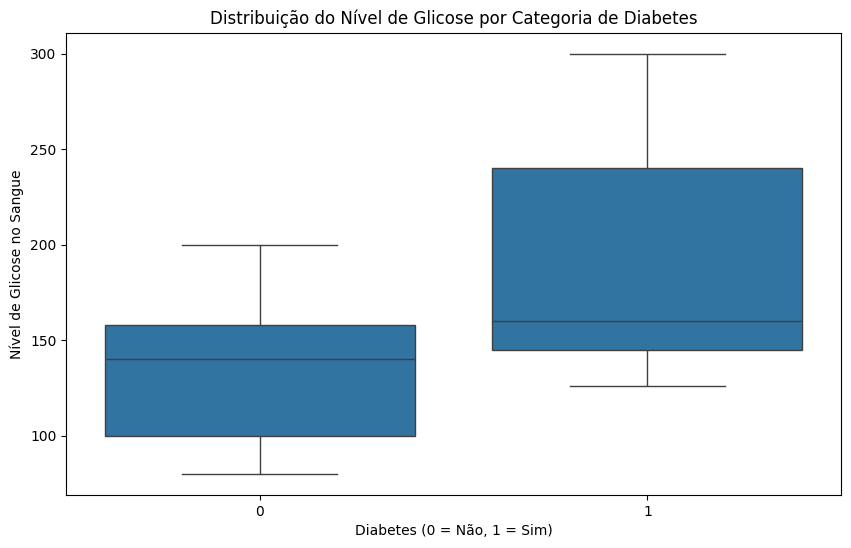

In [43]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df)

plt.title('Distribuição do Nível de Glicose por Categoria de Diabetes')
plt.xlabel('Diabetes (0 = Não, 1 = Sim)')
plt.ylabel('Nível de Glicose no Sangue')
plt.show()

## 4.4 Correlação

Abaixo, o gráfico de correlação nos indica a relação linear entre as variáveis, indicando correlação positiva (quando elas se movem na mesma direção) ou negativa, ou mesmo se não existe qualquer relação entre elas.

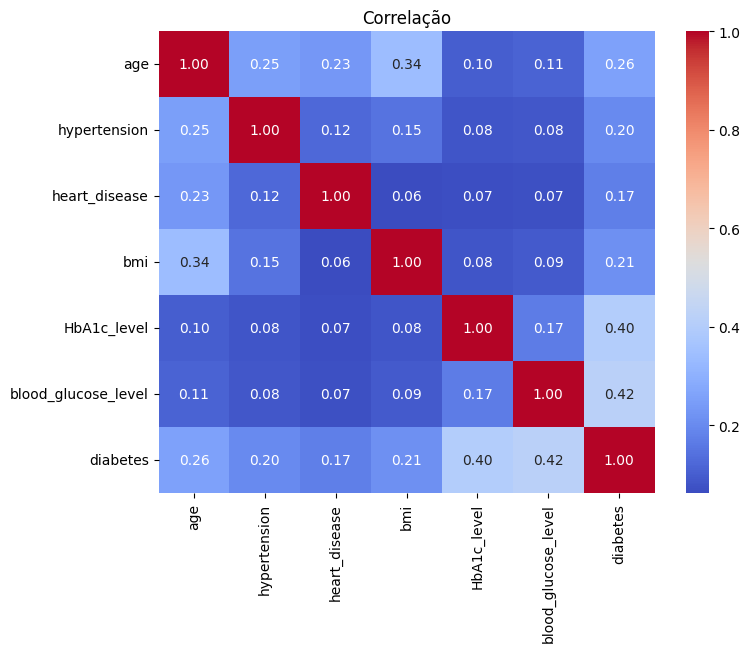

In [44]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação')
plt.show()


# 5. Pré-processamento e Limpeza dos Dados

### Tratamento de valores ausentes (NaN / missing values)

In [45]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0
bmi_category,0


Não há exames com valores nulos ou ausentes para serem tratados.

### Remoção de valores duplicados

In [46]:
sum = df.duplicated().sum()
print(sum)
df.drop_duplicates(inplace=True)


3854


Encontrado e removido 3854 linhas duplicadas do dataset.

### Detecção e tratamento de outliers

### Outliers em bmi (Índice de Massa Corporal)

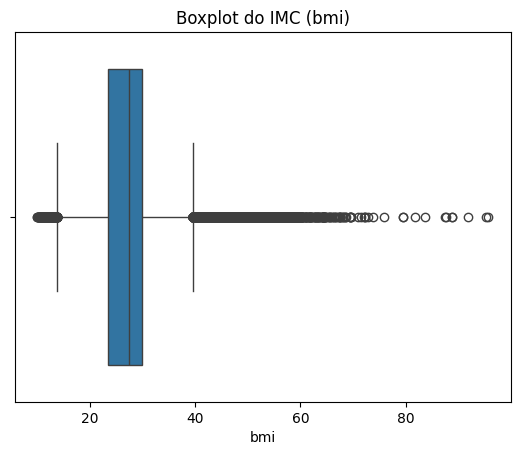

In [47]:
sns.boxplot(x=df['bmi'])
plt.title("Boxplot do IMC (bmi)")
plt.show()

Podemos analisar pontos que se afastam significativamente da tendência geral, a baixo do primeiro quartil como a cima do terceiro quartil.

Vamos utilizar do método de **distância interquartil (IQR)**
na qual uma técnica estatística usada para identificar outliers em um conjunto de dados. Ele se baseia nos quartis do conjunto de dados e no intervalo interquartil (IQR), que é definido como a diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1)

In [48]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['bmi'] >= Q1 - 1.5*IQR) & (df['bmi'] <= Q3 + 1.5*IQR)]


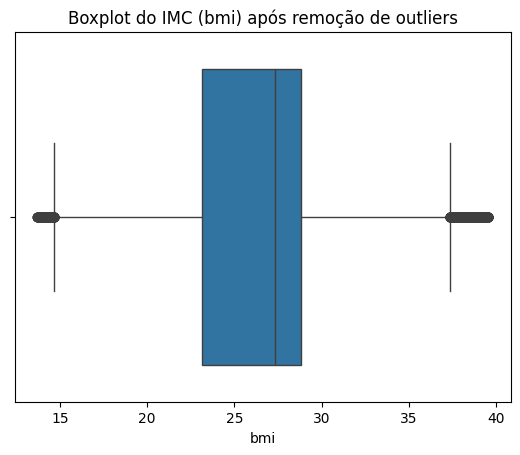

In [49]:
sns.boxplot(x=df['bmi'])
plt.title("Boxplot do IMC (bmi) após remoção de outliers")
plt.show()


Após a aplicação do método, os valores extremos foram removidos, mantendo apenas observações dentro do intervalo aceitável.

### Outliers em age (Idade)

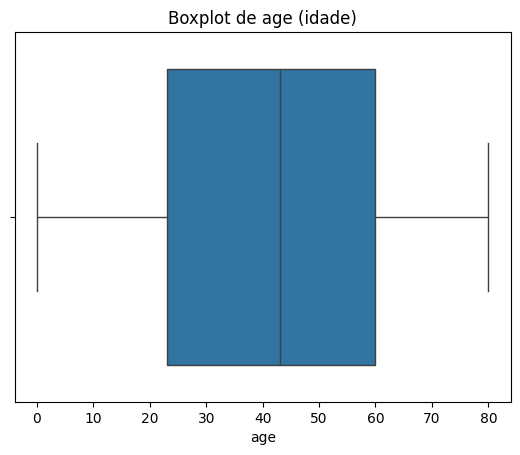

In [50]:
sns.boxplot(x=df['age'])
plt.title("Boxplot de age (idade)")
plt.show()

Podemos analisar que não há necessidade de tratamento de outliers para idade, por não conter pontos que se afastam da tendência geral.

### Outliers em blood_glucose_level (Nível de glicose no sangue)

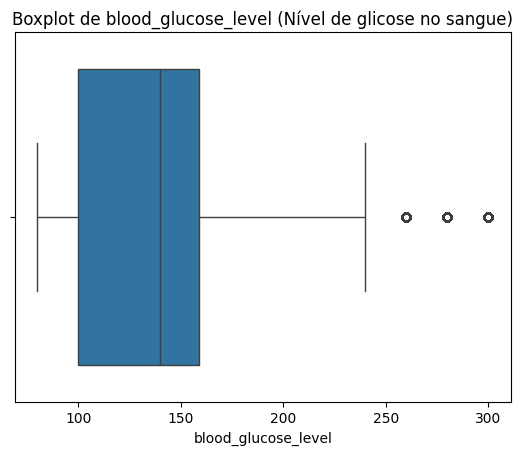

In [51]:
sns.boxplot(x=df['blood_glucose_level'])
plt.title("Boxplot de blood_glucose_level (Nível de glicose no sangue)")
plt.show()

Podemos analisar pontos que se afastam significativamente da tendência geral, a baixo do primeiro quartil como a cima do terceiro quartil.
Vamos utilizar do método de distância interquartil (IQR) para o tratamento dos outliers.

In [52]:
Q1 = df['blood_glucose_level'].quantile(0.25)
Q3 = df['blood_glucose_level'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['blood_glucose_level'] >= Q1 - 1.5*IQR) & (df['blood_glucose_level'] <= Q3 + 1.5*IQR)]

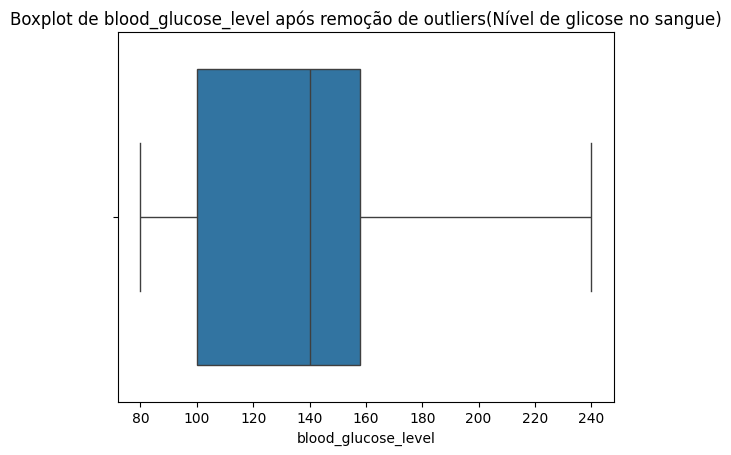

In [53]:
sns.boxplot(x=df['blood_glucose_level'])
plt.title("Boxplot de blood_glucose_level após remoção de outliers(Nível de glicose no sangue)")
plt.show()

**Remoção de dados irrelevantes na coluna "gender"**

As 18 linhas onde a coluna `gender` possui o valor `Other` serão removidas. A decisão se baseia nos seguintes motivos:

- **Insignificância Estatística**: Este volume representa apenas 0.018% do total de dados, sendo estatisticamente irrelevante.
- **Simplificação da Feature**: A exclusão transforma a coluna `gender` em uma variável puramente binária, simplificando a etapa de codificação e a interpretação do modelo.
- **Prevenção de Ruído**: Manter essa categoria criaria uma feature extremamente esparsa após o one-hot encoding, o que pode afetar a capacidade preditiva, sendo considerado ruído pelo algoritmo.

In [54]:
df_cleaned = df.copy()

In [55]:
df_cleaned = df_cleaned[df_cleaned['gender'] != 'Other']

In [56]:
df_cleaned['gender'].value_counts()

,count
gender,
Female,51610
Male,37444


In [57]:
df_cleaned.shape

(89054, 10)

## Criação de faixas etárias (Binning) para a variável "age"

Vamos converter a variável contínua `age` em uma variável categórica chamada `faixa_etaria`. Esta técnica de feature engineering foi adotada para capturar melhor a relação não-linear entre a idade e a probabilidade de ter diabetes, um padrão identificado na análise exploratória.

Os principais benefícios desta abordagem são:

- **Captura de Padrões de Risco**: O risco de diabetes não aumenta de forma constante a cada ano. Ao agrupar as idades, permitimos que o modelo aprenda pesos específicos para diferentes fases da vida (como "Adulto" e "Idoso"), que representam grupos de risco distintos e com maior poder preditivo.
- **Melhora para Modelos Lineares**: Essa transformação ajuda modelos como a Regressão Logística a modelar relações mais complexas. O modelo pode agora associar um coeficiente de risco forte à categoria "Idoso", algo que seria mais difícil de aprender com a variável contínua original.

In [58]:
bins = [0, 12, 19, 39, 59, 81]
labels = ['Criança', 'Adolescente', 'Jovem', 'Adulto', 'Idoso']
df_cleaned['age_bins'] = pd.cut(df_cleaned['age'], bins=bins, labels=labels, right=False)
df_cleaned = df_cleaned.drop(columns=['age', 'bmi_category'], errors='ignore')

## Codificação de Variáveis Categóricas (One-Hot Encoding)

Para que as variáveis categóricas (`gender`, `smoking_history`, e a recém-criada `age bins`) possam ser utilizadas pelos algoritmos de machine learning, elas serão convertidas para um formato numérico.

Essa abordagem foi escolhida por ser melhor para dados nominais, pois evita que o modelo assuma uma relação de ordem ou importância inexistente entre as categorias (por exemplo, que "Idoso" seja numericamente "maior" que "Adulto").  Para evitar redundância de informação (multicolinearidade), uma categoria de cada variável original foi omitida.


In [59]:
df_processed = df_cleaned.copy()
df_processed = pd.get_dummies(df_processed, columns=['gender', 'smoking_history', 'age_bins'], drop_first=True)

In [60]:
df_processed.head()

,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,age_bins_Adolescente,age_bins_Jovem,age_bins_Adulto,age_bins_Idoso
0,0,1,25.19,6.6,140,0,False,False,False,False,True,False,False,False,False,True
1,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False,False,True,False
2,0,0,27.32,5.7,158,0,True,False,False,False,True,False,False,True,False,False
3,0,0,23.45,5.0,155,0,False,True,False,False,False,False,False,True,False,False
4,1,1,20.14,4.8,155,0,True,True,False,False,False,False,False,False,False,True


## Separação da feature e variável alvo

In [61]:
X = df_processed.drop('diabetes', axis=1)
y = df_processed['diabetes']

## Separação dos dados para treino e teste

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Escalonamento

Vamos escalonar as variáveis númericas no `dataframe`, isso não prejudicará os modelos baseados em árvores, mas garantirá que os outros modelos funcionem de maneira otimizada, estável e interpretável.

In [63]:
numeric_cols = ['bmi', 'HbA1c_level', 'blood_glucose_level']

In [64]:
scaler = StandardScaler()

# Ajustamos o scaler APENAS nos dados de treino
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Usar o scaler já ajustado para transformar os dados de teste
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [65]:
print("Formato dos dados de treino (X_train):", X_train.shape)
print("Formato dos dados de teste (X_test):", X_test.shape)
print("\n--- Amostra dos dados de treino processados e escalonados ---")
X_train.head()

Formato dos dados de treino (X_train): (71243, 15)
Formato dos dados de teste (X_test): (17811, 15)

--- Amostra dos dados de treino processados e escalonados ---


,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,age_bins_Adolescente,age_bins_Jovem,age_bins_Adulto,age_bins_Idoso
14463,0,0,0.185689,-1.428939,0.142768,False,False,False,False,False,True,False,True,False,False
64593,1,0,0.143701,0.675746,0.678337,False,False,False,False,True,False,False,False,False,True
27963,0,0,0.185689,0.293076,-1.266626,False,False,False,False,True,False,False,True,False,False
11477,1,0,0.185689,0.675746,-1.548505,False,False,False,False,True,False,False,False,False,True
95934,0,1,0.449071,-0.950601,0.142768,True,False,False,False,True,False,False,True,False,False


# 6. Modelagem

## Logistic Regression

In [66]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [67]:
y_pred = log_reg.predict(X_test)

In [68]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Acurácia do modelo de Regressão Logística: {accuracy:.4f}\n")
print("--- Relatório de Classificação ---")
print(report)

print("--- Matriz de Confusão ---")
print(confusion_matrix(y_test, y_pred))

Acurácia do modelo de Regressão Logística: 0.9624

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     16712
           1       0.84      0.49      0.61      1099

    accuracy                           0.96     17811
   macro avg       0.90      0.74      0.80     17811
weighted avg       0.96      0.96      0.96     17811

--- Matriz de Confusão ---
[[16608   104]
 [  565   534]]


## Logistic Regression (com balanceamento de classes)

In [69]:
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [70]:
y_pred = log_reg.predict(X_test)

In [71]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Acurácia do modelo de Regressão Logística: {accuracy:.4f}\n")
print("--- Relatório de Classificação ---")
print(report)

print("--- Matriz de Confusão ---")
print(confusion_matrix(y_test, y_pred))

Acurácia do modelo de Regressão Logística: 0.8636

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     16712
           1       0.29      0.87      0.44      1099

    accuracy                           0.86     17811
   macro avg       0.64      0.87      0.68     17811
weighted avg       0.95      0.86      0.89     17811

--- Matriz de Confusão ---
[[14428  2284]
 [  146   953]]


##### Qual Modelo é "Melhor"?

Neste ponto, dependeríamos de uma perspevtiva de negócio para escolher uma das opções, considerando o contexto desejado.

- Sem `balanced`: É mais assertivo ao detectar a doença, evitando falsos positivos (Alta Precisão, Baixo Recall).

- Com `balanced`: Aumentar os falso-positvos, mas parece relativamente "barato" solicitar novos exames e evitar que alguém com a doença, fique sem essa informação (Baixa Precisão, Alto Recall).

## Random Forest Classifier

In [72]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

In [73]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [74]:
y_pred_rf = rf_model.predict(X_test)

In [75]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"\nAcurácia do modelo RandomForestClassifier: {accuracy_rf:.4f}\n")
print("--- Relatório de Classificação ---")
print(report_rf)

print("--- Matriz de Confusão ---")
print(confusion_matrix(y_test, y_pred_rf))


Acurácia do modelo RandomForestClassifier: 0.9625

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     16712
           1       0.75      0.59      0.66      1099

    accuracy                           0.96     17811
   macro avg       0.86      0.79      0.82     17811
weighted avg       0.96      0.96      0.96     17811

--- Matriz de Confusão ---
[[16491   221]
 [  447   652]]


## KNN

In [76]:
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

In [77]:
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1)

In [78]:
y_pred_knn = knn_model.predict(X_test)

In [79]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

print(f"\nAcurácia do modelo KNN: {accuracy_knn:.4f}\n")
print("--- Relatório de Classificação (KNN) ---")
print(report_knn)

print("--- Matriz de Confusão (KNN) ---")
print(confusion_matrix(y_test, y_pred_knn))


Acurácia do modelo KNN: 0.9621

--- Relatório de Classificação (KNN) ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     16712
           1       0.84      0.48      0.61      1099

    accuracy                           0.96     17811
   macro avg       0.90      0.74      0.79     17811
weighted avg       0.96      0.96      0.96     17811

--- Matriz de Confusão (KNN) ---
[[16609   103]
 [  572   527]]


## MLPClassifier

In [80]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    max_iter=500,
    random_state=42,
)

In [81]:
mlp_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)

In [82]:
y_pred_mlp = mlp_model.predict(X_test)

In [83]:
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
report_mlp = classification_report(y_test, y_pred_mlp)

print(f"\nAcurácia do modelo MLPClassifier: {accuracy_mlp:.4f}\n")
print("--- Relatório de Classificação (MLP) ---")
print(report_mlp)

print("--- Matriz de Confusão (MLP) ---")
print(confusion_matrix(y_test, y_pred_mlp))


Acurácia do modelo MLPClassifier: 0.9725

--- Relatório de Classificação (MLP) ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     16712
           1       0.98      0.56      0.72      1099

    accuracy                           0.97     17811
   macro avg       0.98      0.78      0.85     17811
weighted avg       0.97      0.97      0.97     17811

--- Matriz de Confusão (MLP) ---
[[16702    10]
 [  480   619]]


# 7. Avaliação do Modelo

O `MLPClassifier` se destaca como o melhor modelo geral por apresentar o maior `F1-Score`, indicando melhor equilíbrio entre encontrar os pacientes doentes (Recall) e estar certo ao fazê-lo (Precision).

Abaixo trazemos mais detalhes sobre ele e os outros modelos testados.

---

<br />

**Tabela Comparativa**

| Modelo | Acurácia | Precision | Recall | F1-Score | Falsos Negativos |
| --- | --- | --- | --- | --- | --- |
| Regressão Logística | 96.0% | 0.84 | 0.49 | 0.61 | 565 |
| Regressão Logística (Balance) | 86.4% | 0.29 | **0.87** | 0.44 | **146** |
| Random Forest | 96.2% | 0.75 | 0.59 | 0.66 | 447 |
| KNN | 96.2% | 0.84 | 0.48 | 0.61 | 572 |
| **MLP Classifier** | **97.2%** | **0.98** | 0.56 | **0.72** | 480 |


---

<br />

### Avaliação de Cada Modelo

#### Regressão Logística e KNN:

Análise: Esses dois modelos tiveram um desempenho quase idêntico. Eles são muito conservadores. Possuem alta precisão (84%), ou seja, quando dizem que alguém tem diabetes, eles geralmente estão certos. No entanto, o recall é péssimo (48-49%), o que significa que eles deixaram passar mais da metade dos pacientes doentes (565-572 falsos negativos).

Parece inadequados para um cenário de triagem médica, devido ao alto risco de não diagnosticar um paciente.

---

#### Regressão Logística (com Balance):

Análise: Este modelo foi para o extremo oposto. Ele se tornou um excelente "detector", com um recall altíssimo de 87% e o menor número de falsos negativos (146), deixando poucos casos passarem. Em contrapartida a precisão despencou para 29%. Isso significa que para cada 100 pacientes que ele sinaliza como diabéticos, 71 são alarmes falsos.

---

#### Random Forest Classifier:

Um bom meio-termo. Conseguiu um recall (59%) melhor que a regressão logística base, mantendo uma precisão razoável (75%). O F1-score de 0.66 mostra um bom equilíbrio.

Um modelo muito melhor e mais balanceado que a Regressão Logística e o KNN.

---

#### MLPClassifier (Rede Neural):

Este é o modelo que mais se destaca.

- Com Precisão (98%): De todos os que ele classificou como diabéticos, 98% realmente eram. Ele gerou apenas 10 Falsos Positivos!

- Recall (56%): Embora não seja o melhor, ainda é consideravelmente superior ao da Regressão Logística base e do KNN.

- F1-Score (0.72): O mais alto de todos, indicando o melhor equilíbrio geral entre precisão e recall.



# 8. Conclusão

O `MLPClassifier` é o modelo mais robusto e confiável. Embora perca um pouco no recall em comparação com o `Random Forest`, sua altíssima precisão significa que os alertas gerados por ele são confiáveis, minimizando exames desnecessários em pacientes saudáveis.
